# Q2: Vision in the Real World - Indian Currency Classification

### 2A.1 Spatial Dimension Calculation

The output spatial dimension of a convolutional layer is given by:

$$
O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1
$$

#### (a)

Input: $3 \times 128 \times 128$  
Conv Layer:
- Number of filters = 32  
- Kernel size = $3 \times 3$  
- Stride = 2  
- Padding = 1  

Output spatial size:

$$
O = \left\lfloor \frac{128 - 3 + 2(1)}{2} \right\rfloor + 1
= \left\lfloor \frac{127}{2} \right\rfloor + 1
= 63 + 1 = 64
$$

Output volume:

$$
32 \times 64 \times 64
$$

#### (b)

Input: $32 \times 64 \times 64$  
Conv Layer:
- Number of filters = 64  
- Kernel size = $3 \times 3$  
- Stride = 1  
- Padding = 1  

Output spatial size:

$$
O = \left\lfloor \frac{64 - 3 + 2(1)}{1} \right\rfloor + 1
= \left\lfloor 63 \right\rfloor + 1 = 64
$$

Output volume:

$$
64 \times 64 \times 64
$$

### 2A.2 Receptive Field

#### (a)

The receptive field of a neuron in a convolutional layer is the region of the input image that influences that neuron’s output.

A larger receptive field allows the network to capture more global context and higher-level features, which is important for understanding larger patterns and objects in the image.

#### (b)

For two stacked $3 \times 3$ convolutions (stride = 1, no pooling):

- First layer receptive field = $3 \times 3$
- Second layer increases it by $(3 - 1) = 2$

Total receptive field:

$$
3 + 2 = 5
$$

So, the effective receptive field is:

$$
5 \times 5
$$

For a single $5 \times 5$ convolution:

- Receptive field = $5 \times 5$

#### Comparison:

Both approaches achieve the same receptive field, but two stacked $3 \times 3$ convolutions use fewer parameters.

- Two $3 \times 3$ layers: $2 \times (3 \times 3) = 18$ parameters per channel pair  
- One $5 \times 5$ layer: $25$ parameters per channel pair  

Thus, stacking smaller kernels is more parameter-efficient.

### 2A.3 Parameter Efficiency

#### (a) Standard Conv2D

Input channels = 32  
Output channels = 64  
Kernel size = $3 \times 3$

Number of weights:

$$
32 \times 64 \times 3 \times 3 = 32 \times 64 \times 9 = 18432
$$

Number of biases:

$$
64
$$

Total parameters:

$$
18432 + 64 = 18496
$$

---

#### (b) Depthwise Separable Convolution

This consists of:

1. **Depthwise Convolution** (per-channel convolution)
2. **Pointwise Convolution** ($1 \times 1$ convolution)

**Depthwise convolution:**

- Each of the 32 channels has its own $3 \times 3$ filter

Weights:

$$
32 \times 3 \times 3 = 288
$$

Biases:

$$
32
$$

Total (depthwise):

$$
288 + 32 = 320
$$

---

**Pointwise convolution:**

- Maps 32 channels → 64 channels using $1 \times 1$ filters

Weights:

$$
32 \times 64 = 2048
$$

Biases:

$$
64
$$

Total (pointwise):

$$
2048 + 64 = 2112
$$

---

**Total parameters (depthwise separable):**

$$
320 + 2112 = 2432
$$

---

#### (c) Compression Ratio

$$
\text{Compression Ratio} = \frac{18496}{2432} \approx 7.6
$$

---

#### Explanation

Depthwise separable convolutions drastically reduce the number of parameters by factorizing a standard convolution into channel-wise spatial filtering and cross-channel mixing. This makes models much more efficient while maintaining comparable performance, which is why MobileNet-style architectures rely heavily on this design.

### 2A.4 BatchNorm vs LayerNorm - Choosing the Right Normalization

#### (a) BatchNorm axis

For a CNN with input shape $(B, C, H, W)$, BatchNorm computes mean and variance over the batch and spatial dimensions for each channel.

Thus, normalization is performed over the axes:

$$
(B, H, W)
$$

for each channel $C$.

---

#### (b) Small-batch failure mode

When the batch size is very small (e.g., $B = 2$), BatchNorm statistics become noisy and unreliable because they are estimated from very few samples. This leads to unstable training and poor generalization.

A robust alternative is **Group Normalization**, which normalizes over groups of channels and does not depend on the batch size.

---

#### (c) Why not BatchNorm in Transformers?

In Transformers, sequences in a batch can have different lengths, even after padding. Computing BatchNorm statistics across the batch and sequence dimensions mixes information from unrelated tokens and padding positions, leading to inconsistent normalization.

LayerNorm, on the other hand, normalizes across the feature dimension for each token independently, making it invariant to batch size and sequence length, which is why it is preferred in Transformers.

## Part B: Practical Implementation

### Dataset Description

We use the **Indian Currency Notes Dataset**, consisting of 7 classes:
INR 10, 20, 50, 100, 200, 500, and 2000.

- Training images: 120 per class (Total = 840)
- Test images: 30 per class (Total = 210)

### Dataset Structure

The dataset follows the standard **ImageFolder** format:

    currency_dataset_extended/
    ├── train/
    │   ├── 10/
    │   ├── 20/
    │   ├── 50/
    │   ├── 100/
    │   ├── 200/
    │   ├── 500/
    │   └── 2000/
    │
    └── test/
        ├── 10/
        ├── 20/
        ├── 50/
        ├── 100/
        ├── 200/
        ├── 500/
        └── 2000/

Each subdirectory represents a class label corresponding to a currency denomination.

**Note:** The original images are of varying sizes.  
They are resized to **128×128 dynamically using torchvision transforms during training**.

Dataset link:
https://drive.google.com/file/d/1NB0p6rly0etGFSG-MLl4PJXSTnzLamq-/view?usp=sharing

In [39]:
# imports and setup

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
from sklearn.metrics import confusion_matrix
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# Transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),  # resizing to 128x128
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
# Load dataset

train_dataset = datasets.ImageFolder(
    root='data/currency_dataset_extended/train',
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root='data/currency_dataset_extended/test',
    transform=transform
)

In [6]:
# Dataset information
print("Classes:", train_dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

Classes: ['10', '100', '20', '200', '2000', '50', '500']
Number of training samples: 840
Number of test samples: 210


In [7]:
# Dataloaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

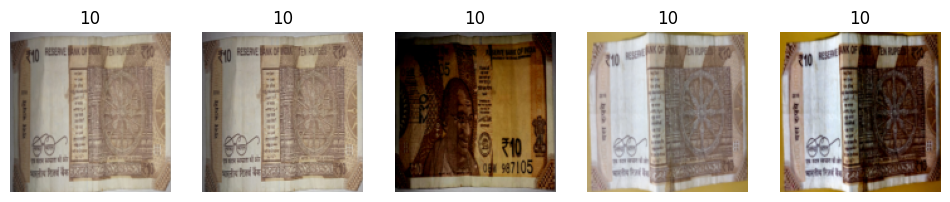

In [8]:
# Visualize some samples

import matplotlib.pyplot as plt

def show_images(dataset):
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    for i in range(5):
        img, label = dataset[i]
        img = img.permute(1, 2, 0) * 0.5 + 0.5  # unnormalize
        axes[i].imshow(img)
        axes[i].set_title(train_dataset.classes[label])
        axes[i].axis("off")
    plt.show()

show_images(train_dataset)

### 2B.1 Baseline CNN

We design a CNN with 4 convolutional blocks. Each block consists of:

Conv2D -> BatchNorm -> ReLU -> MaxPooling(2×2)

The final feature maps are passed through a Global Average Pooling layer,
followed by a single fully connected layer for classification.

### Layer-wise Details

Input: RGB image of size **3 × 128 × 128**

| Block | Operation | Output Channels | Output Size |
|------|----------|----------------|-------------|
| Input | — | 3 | 128 × 128 |
| Block 1 | Conv → BN → ReLU → MaxPool | 32 | 64 × 64 |
| Block 2 | Conv → BN → ReLU → MaxPool | 64 | 32 × 32 |
| Block 3 | Conv → BN → ReLU → MaxPool | 128 | 16 × 16 |
| Block 4 | Conv → BN → ReLU → MaxPool | 256 | 8 × 8 |
| GAP | Global Avg Pooling | 256 | 1 × 1 |
| FC | Fully Connected | 7 | — |

---

### Key Design Choices

- **Batch Normalization** is used after each convolution to stabilize training and improve convergence.
- **ReLU activation** introduces non-linearity.
- **MaxPooling** reduces spatial dimensions and helps in extracting hierarchical features.
- **Global Average Pooling (GAP)** replaces fully connected layers to:
  - reduce the number of parameters,
  - prevent overfitting,
  - enforce spatial feature aggregation.
- A single **fully connected layer** maps the features to the 7 output classes.

---

### Output

The final output is a vector of size **7**, corresponding to the 7 currency denominations.  
Softmax is implicitly applied via the CrossEntropyLoss during training.

In [15]:
# Model Definition

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Final classifier
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [16]:
# Instantiate Model

model = BaselineCNN(num_classes=7).to(device)

In [17]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
# Training loop

def train_model(model, train_loader, test_loader, epochs=15):
    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)

        # Evaluate
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}: Loss={running_loss:.2f}, Accuracy={accuracy:.2f}%")

    return train_losses, test_accuracies

# Train
train_losses, test_accuracies = train_model(model, train_loader, test_loader)

Epoch 1: Loss=21.66, Accuracy=52.38%
Epoch 2: Loss=12.93, Accuracy=74.76%
Epoch 3: Loss=9.99, Accuracy=90.95%
Epoch 4: Loss=7.43, Accuracy=89.52%
Epoch 5: Loss=9.11, Accuracy=93.33%
Epoch 6: Loss=7.73, Accuracy=97.14%
Epoch 7: Loss=6.30, Accuracy=96.67%
Epoch 8: Loss=4.34, Accuracy=96.19%
Epoch 9: Loss=5.89, Accuracy=97.62%
Epoch 10: Loss=3.56, Accuracy=98.10%
Epoch 11: Loss=3.33, Accuracy=94.29%
Epoch 12: Loss=2.80, Accuracy=98.57%
Epoch 13: Loss=3.00, Accuracy=98.57%
Epoch 14: Loss=2.63, Accuracy=97.62%
Epoch 15: Loss=1.60, Accuracy=99.52%


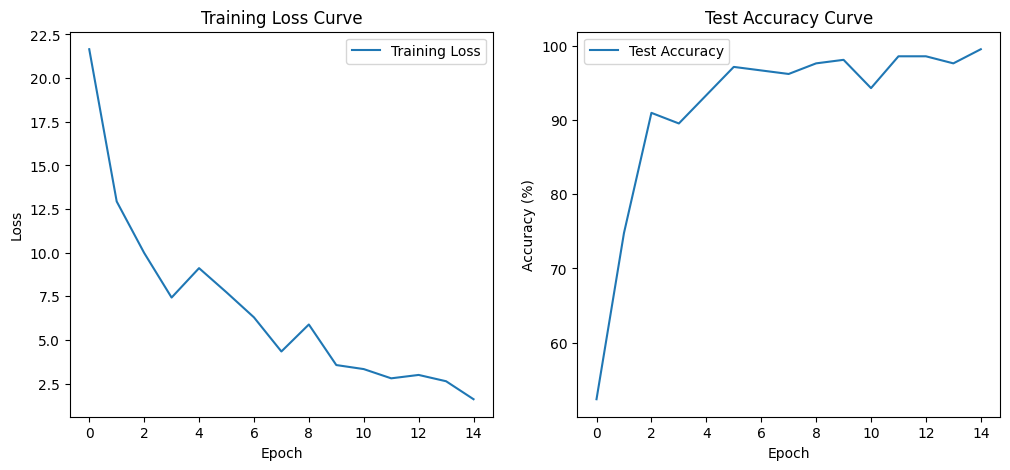

In [19]:
# Plot results
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy Curve")
plt.legend()

plt.show()

### Results and Observations

The model shows consistent convergence, with training loss decreasing steadily
over epochs. The test accuracy improves rapidly in the initial epochs and
stabilizes at a high value towards the end of training.

Minor fluctuations in accuracy are observed across epochs, which can be attributed
to stochastic optimization and batch-wise variations.

Due to randomness in initialization and data shuffling, exact numerical values
may vary across runs, but the overall trend remains consistent.

### 2B.2 Mobile-Friendly CNN

In this section, we design a parameter-efficient CNN by replacing the last two
standard convolutional blocks with **Depthwise Separable Convolutions**.

A depthwise separable convolution consists of:
1. **Depthwise Convolution**: Applies a single convolutional filter per input channel.
2. **Pointwise Convolution (1×1)**: Combines the outputs across channels.

In [20]:
# Depthwise Separable Convolution
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1,
            groups=in_channels
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

In [21]:
# Mobile-Friendly CNN (last 2 blocks replaced)

class MobileCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3 (Depthwise Separable)
            DepthwiseSeparableConv(64, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4 (Depthwise Separable)
            DepthwiseSeparableConv(128, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [22]:
# Train Mobile Model

model_mobile = MobileCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mobile.parameters(), lr=0.001)

train_losses_m, test_acc_m = train_model(model_mobile, train_loader, test_loader)

Epoch 1: Loss=29.83, Accuracy=68.57%
Epoch 2: Loss=13.63, Accuracy=85.71%
Epoch 3: Loss=10.82, Accuracy=89.52%
Epoch 4: Loss=8.77, Accuracy=95.24%
Epoch 5: Loss=6.45, Accuracy=98.57%
Epoch 6: Loss=6.77, Accuracy=98.10%
Epoch 7: Loss=5.64, Accuracy=98.57%
Epoch 8: Loss=4.04, Accuracy=95.71%
Epoch 9: Loss=3.42, Accuracy=97.62%
Epoch 10: Loss=3.90, Accuracy=95.71%
Epoch 11: Loss=2.91, Accuracy=99.05%
Epoch 12: Loss=2.10, Accuracy=98.10%
Epoch 13: Loss=2.01, Accuracy=97.62%
Epoch 14: Loss=1.46, Accuracy=97.62%
Epoch 15: Loss=2.23, Accuracy=99.52%


In [23]:
# Parameter Count

baseline_params = sum(p.numel() for p in model.parameters())
mobile_params = sum(p.numel() for p in model_mobile.parameters())

print("Baseline parameters:", baseline_params)
print("Mobile model parameters:", mobile_params)
print("Compression ratio:", baseline_params / mobile_params)

Baseline parameters: 391175
Mobile model parameters: 65415
Compression ratio: 5.979897577008331


#### (a) Parameter Count

The total number of learnable parameters for both models is computed using:

    sum(p.numel() for p in model.parameters())

- Baseline CNN parameters: **391,175**
- Mobile-friendly CNN parameters: **65,415**

The mobile-friendly model uses significantly fewer parameters due to the use of
depthwise separable convolutions in the last two convolutional blocks.

---

#### (b) Test Accuracy Comparison

The mobile-friendly CNN achieves test accuracy exactly same as the baseline model (= 99.52 %),
with both models reaching high accuracy on the test set. Re-training both models will have almost same accuracies.

Despite a substantial reduction in the number of parameters, the performance of
the mobile model remains competitive. This demonstrates that depthwise separable
convolutions are effective in preserving representational power while improving
efficiency.

---

#### (c) Compression Ratio

The compression ratio is computed as:

    Compression Ratio = (Baseline Parameters) / (Mobile Model Parameters)

Substituting values:

    Compression Ratio = 391,175 / 65,415 ≈ 5.98

This is lower than the theoretical compression ratio (~7.6) derived in Part 2A.3.
The discrepancy arises because the theoretical calculation considers only a single
convolutional layer, whereas the practical model includes additional components
such as Batch Normalization, biases, fully connected layers, and standard convolution
layers in earlier blocks.

Furthermore, only the last two convolutional blocks were replaced with depthwise
separable convolutions, which reduces the overall compression effect.

Despite this, the observed compression still demonstrates a significant reduction
in parameters while maintaining strong performance.

### 2B.3 Data Augmentation

To improve generalization, we apply data augmentation techniques that simulate
real-world variations such as rotation, lighting changes, and slight translations.

The following augmentation pipeline is used:
- RandomRotation (±30°)
- ColorJitter (brightness=0.3, contrast=0.3)
- RandomHorizontalFlip (p=0.5)
- RandomAffine (translation up to 10%)

These transformations help the model become robust to variations commonly
observed in real-world currency images.

In [24]:
# Define augmented transforms

transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [25]:
# Apply augmentations to train set

train_dataset_aug = datasets.ImageFolder(
    root='data/currency_dataset_extended/train',
    transform=transform_aug
)

test_dataset_noaug = datasets.ImageFolder(
    root='data/currency_dataset_extended/test',
    transform=transform
)

In [26]:
# Dataloaders

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
test_loader_noaug = DataLoader(test_dataset_noaug, batch_size=32, shuffle=False)

In [27]:
# Train mobile model with augmentation

model_aug = MobileCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=0.001)

train_losses_aug, test_acc_aug = train_model(
    model_aug,
    train_loader_aug,
    test_loader_noaug,
    epochs=15
)

Epoch 1: Loss=32.75, Accuracy=72.86%
Epoch 2: Loss=16.71, Accuracy=91.43%
Epoch 3: Loss=13.26, Accuracy=88.57%
Epoch 4: Loss=12.30, Accuracy=91.90%
Epoch 5: Loss=11.13, Accuracy=94.29%
Epoch 6: Loss=10.11, Accuracy=92.38%
Epoch 7: Loss=8.22, Accuracy=97.14%
Epoch 8: Loss=9.01, Accuracy=96.19%
Epoch 9: Loss=7.67, Accuracy=96.67%
Epoch 10: Loss=6.95, Accuracy=97.14%
Epoch 11: Loss=6.70, Accuracy=97.62%
Epoch 12: Loss=6.61, Accuracy=97.62%
Epoch 13: Loss=5.83, Accuracy=94.76%
Epoch 14: Loss=5.79, Accuracy=96.67%
Epoch 15: Loss=4.96, Accuracy=95.24%


In [28]:
# Compare accuracy

print("Final Test Accuracy with Augmentation:", test_acc_aug[-1])

Final Test Accuracy with Augmentation: 95.23809523809524


#### (a) Effect of Data Augmentation

The model trained with data augmentation achieves a test accuracy of approximately
**95.24%**, compared to **99.52%** without augmentation.

Although the accuracy is slightly lower, data augmentation improves the model's
robustness by exposing it to variations such as rotations, lighting changes, and
translations during training. This makes the model less sensitive to overfitting
on the limited training data and better suited for real-world scenarios.

The slight drop in accuracy can be attributed to the increased difficulty of the
augmented training data, which acts as a regularizer.

---

#### (b) Should augmentation be applied to the test set?

No, data augmentation should not be applied to the test set.

The purpose of the test set is to evaluate model performance on real, unseen data.
Applying augmentation would artificially alter the data distribution and lead to
an inaccurate estimate of the model’s true generalization performance.

Therefore, augmentation is applied only to the training set.

### 2B.4 Interpretability with Grad-CAM

To understand which regions of the image the model focuses on for classification,
we use **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM highlights important regions in the input image that contribute most to
the model's prediction by using gradients flowing into the final convolutional layer.

In [36]:
# Choose target layer (last Conv layer)

target_layer = model.features[-4]  

In [37]:
# Pick one corrrectly classified image from each three different denominations

def get_correct_samples(model, dataset, num_classes=3):
    model.eval()
    samples = []
    seen = set()

    for img, label in dataset:
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_input)
            pred = output.argmax(dim=1).item()

        if pred == label and label not in seen:
            samples.append((img, label))
            seen.add(label)

        if len(samples) == num_classes:
            break

    return samples

samples = get_correct_samples(model, test_dataset, num_classes=3)

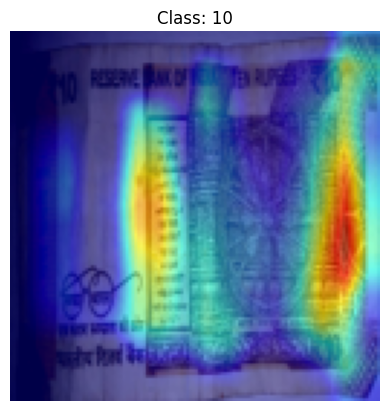

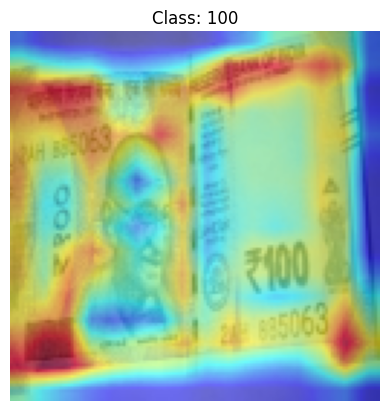

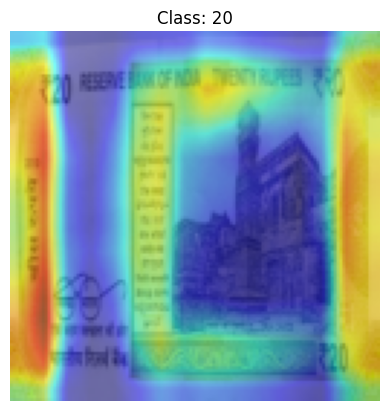

In [38]:
# Generate Grad-CAM

cam = GradCAM(model=model, target_layers=[target_layer])

for img, label in samples:
    input_tensor = img.unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Convert image to numpy
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * 0.5) + 0.5  # unnormalize

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

#### (c) Grad-CAM Analysis

The Grad-CAM visualizations show that the model focuses on meaningful and
discriminative regions of the currency notes.

For the ₹10 note, the model places strong attention on the right-hand side and
central regions, which include distinctive patterns and structural elements of
the note. The edges also receive some attention, likely due to consistent layout
features.

For the ₹100 note, the model attends to a broader region, including the portrait
of Mahatma Gandhi and surrounding text and patterns. This suggests that the model
is using both semantic features (portrait) and contextual cues (text and layout)
for classification.

For the ₹20 note, attention is concentrated along the vertical strip and edges,
as well as the central structure. These regions correspond to unique design
elements and textures specific to this denomination.

Across all three examples, the model consistently focuses on:
- denomination-specific patterns and textures,
- prominent structural elements,
- edges and layout features of the notes.

This indicates that the model has learned relevant visual features rather than
relying on arbitrary regions. The attention patterns are reasonably consistent
across denominations, although the exact regions vary depending on the design of
each note.

Overall, the Grad-CAM results demonstrate that the model is making decisions
based on meaningful visual cues, indicating good interpretability and learning
behavior.

### 2B.5 Confusion Matrix Analysis

To evaluate class-wise performance, we compute the confusion matrix for the best
performing model on the test set.

The confusion matrix helps identify which classes are correctly classified and
which pairs of classes are frequently confused.

In [ ]:
# Compute predictions

y_true = []
y_pred = []

model.eval() # Best model is Baseline CNN without augmentation, so we use that for confusion matrix

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

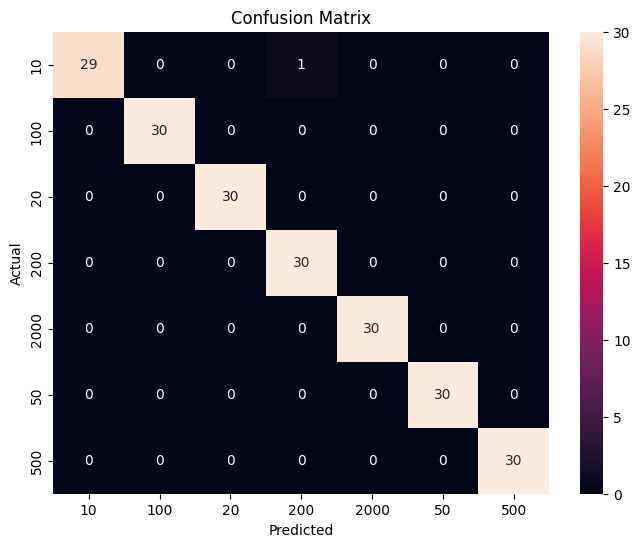

In [41]:
# Plot confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### (b) Identifying Misclassified Samples

From the confusion matrix, we can see that there was only 1 misclassified pair - a 10 rupee note is misclassified as 200. To further dive deep, we find out exactly which sample image was misclassified.

In [42]:
# Identify misclassified samples

misclassified = []

model.eval()

with torch.no_grad():
    for idx, (img, label) in enumerate(test_dataset):
        img_input = img.unsqueeze(0).to(device)

        output = model(img_input)
        pred = output.argmax(dim=1).item()

        if pred != label:
            misclassified.append((idx, label, pred))

# Print misclassified samples
for idx, label, pred in misclassified:
    print(f"Index: {idx}, Actual: {train_dataset.classes[label]}, Predicted: {train_dataset.classes[pred]}")

Index: 19, Actual: 10, Predicted: 200


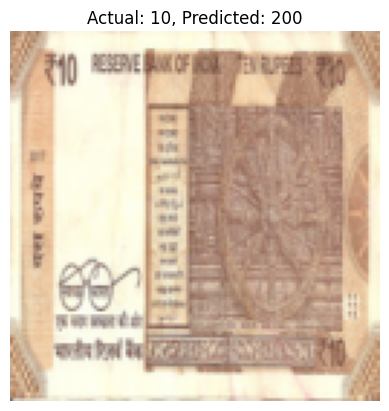

In [43]:
# Visualize the misclassified image

if len(misclassified) > 0:
    idx, label, pred = misclassified[0]

    img, _ = test_dataset[idx]

    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * 0.5 + 0.5  # unnormalize

    plt.imshow(img_np)
    plt.title(f"Actual: {train_dataset.classes[label]}, Predicted: {train_dataset.classes[pred]}")
    plt.axis("off")
    plt.show()
else:
    print("No misclassified samples found.")

Due to the absence of strong distinguishing features, the model likely relied on
global patterns or textures, which may resemble those of a ₹200 note, leading to
the incorrect prediction. This particular 10 rupee note almost looks like a 200 rupee note due to a strikingly similar similarity in color. Due to lighting conditions or otherwise, the brown color of 10 rupee note and the orange color of the 200 rupee note, which look kind of similar, might have consfused the classifier.

Although all images are resized to 128×128, the relative size and prominence of
key features within the image can vary significantly. In this case, the model
likely relied on coarse patterns and textures, which may resemble those of a
₹200 note, leading to the incorrect prediction.

#### (c) Strategy to Reduce Confusion

Although the model achieves near-perfect performance, the single misclassification
highlights a limitation in handling images with degraded visual quality.

In this case, the confusion arises due to poor visibility of key features such as
the denomination numeral, along with variations in the effective size and clarity
of important regions within the image. As a result, the model relies on coarse
textures and global patterns, which can lead to incorrect predictions.

To reduce such confusion, the following strategies can be applied:

- **Targeted data augmentation**: Introduce augmentations such as blur, noise,
  and varying scales during training to make the model robust to poor-quality inputs.
- **Focus on discriminative regions**: Encourage the model to attend to key areas
  like denomination numerals using attention mechanisms or region-focused training.
- **Higher-resolution inputs**: Using higher-resolution images can help preserve
  fine-grained details, making it easier to distinguish between similar patterns.

These approaches can improve the model’s robustness and help eliminate rare
misclassifications caused by loss of critical visual information.